--- Model Parameters (Manual Calculation) ---
Slope (m): 27151.5374
Intercept (c): 74208.6250

Test Set R-squared Score: 0.9024


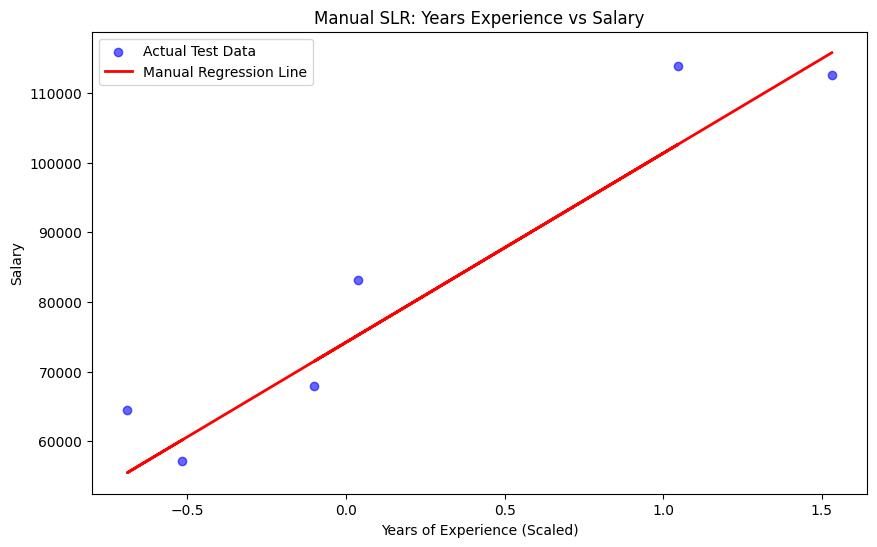


Prediction for 5.0 years of experience: $71499.28


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. LOAD AND PREPARE DATA
# Assuming your dataset is named 'Salary_Data.csv'
# It should contain 'YearsExperience' and 'Salary' columns
df = pd.read_csv('Salary_Dataset.csv')
df = df.dropna()

# Using Years of Experience to predict Salary
X = df[['YearsExperience']].values # Independent Variable
y = df['Salary'].values            # Dependent Variable

# 2. USING SKLEARN FOR PREPROCESSING
# Split data into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features (StandardScaler helps center the data for the manual formula)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).flatten()
X_test_scaled = scaler.transform(X_test).flatten()

# 3. MANUAL SLR LOGIC (Without using sklearn.linear_model)
# We calculate slope (m) and intercept (c) using the training set
mean_x = np.mean(X_train_scaled)
mean_y = np.mean(y_train)

# Calculate terms for Slope (m): m = Σ((x - x_mean) * (y - y_mean)) / Σ((x - x_mean)^2)
numerator = np.sum((X_train_scaled - mean_x) * (y_train - mean_y))
denominator = np.sum((X_train_scaled - mean_x) ** 2)

m = numerator / denominator
c = mean_y - (m * mean_x)

print("--- Model Parameters (Manual Calculation) ---")
print(f"Slope (m): {m:.4f}")
print(f"Intercept (c): {c:.4f}")

# 4. PREDICTIONS & EVALUATION
# Apply y = mx + c to the test set
y_pred = m * X_test_scaled + c

# Calculate R-squared manually: 1 - (Sum of Squared Residuals / Total Sum of Squares)
ssr = np.sum((y_test - y_pred) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)

print(f"\nTest Set R-squared Score: {r2:.4f}")

# 5. VISUALIZATION
plt.figure(figsize=(10, 6))
plt.scatter(X_test_scaled, y_test, color='blue', alpha=0.6, label='Actual Test Data')
plt.plot(X_test_scaled, y_pred, color='red', linewidth=2, label='Manual Regression Line')
plt.title('Manual SLR: Years Experience vs Salary')
plt.xlabel('Years of Experience (Scaled)')
plt.ylabel('Salary')
plt.legend()
plt.show()

# 6. PREDICTION FUNCTION
def predict_salary(years_exp):
    # Scale the input using the same scaler used for training
    scaled_val = scaler.transform([[years_exp]])[0][0]
    return m * scaled_val + c

test_years = 5.0
print(f"\nPrediction for {test_years} years of experience: ${predict_salary(test_years):.2f}")